In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Task 1: Store and Process Data (PySpark)
!pip install pyspark

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Initialize Spark Session
spark = SparkSession.builder.master("local[*]").appName("SmartCityPro").getOrCreate()

# Load the dataset
# Note: Kaggle automatically puts the data in this path
path = "/kaggle/input/datasets/mobeenfatimah/cityflow-smart-urban-mobility-and-traffic-iot/smart_city_traffic_mobility.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

# Data Cleaning: Let's see the scale of our data
print(f"Dataset Loaded Successfully. Total Records: {df.count()}")
df.select("city_zone", "road_type", "speed_limit", "vehicle_count").show(5)

Dataset Loaded Successfully. Total Records: 204000
+------------------+------------+-----------+-------------+
|         city_zone|   road_type|speed_limit|vehicle_count|
+------------------+------------+-----------+-------------+
|Financial District|Local Street|         40|          162|
|Financial District|Local Street|         40|          150|
|Financial District|Local Street|         40|          186|
|Financial District|Local Street|         40|          162|
|Financial District|Local Street|         40|          168|
+------------------+------------+-----------+-------------+
only showing top 5 rows


Data Engineering before running the Machine Learning model.

In [3]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import StringIndexer

# 1. Cleaning: Drop any rows with missing (null) values
df_clean = df.dropna()

# 2. Feature Engineering: Create a 'Congestion_Score'
# Logic: Higher vehicle count on a low speed limit road = High Congestion
# We multiply count by (100 / speed_limit) to normalize it
df_engineered = df_clean.withColumn(
    "congestion_score", 
    (col("vehicle_count") * (100 / col("speed_limit")))
)

# 3. Categorical Encoding: Convert Zone names to Numbers
# 'Financial District' becomes 0, 'Suburban North' becomes 1, etc.
indexer = StringIndexer(inputCol="city_zone", outputCol="zone_idx")
df_final = indexer.fit(df_engineered).transform(df_engineered)

# 4. Summary of 'Perfected' Data
print(f"Data Engineering Complete. Rows remaining: {df_final.count()}")
df_final.select("city_zone", "zone_idx", "vehicle_count", "speed_limit", "congestion_score").show(5)

26/09/16 15:23:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Data Engineering Complete. Rows remaining: 204000
+------------------+--------+-------------+-----------+----------------+
|         city_zone|zone_idx|vehicle_count|speed_limit|congestion_score|
+------------------+--------+-------------+-----------+----------------+
|Financial District|     1.0|          162|         40|           405.0|
|Financial District|     1.0|          150|         40|           375.0|
|Financial District|     1.0|          186|         40|           465.0|
|Financial District|     1.0|          162|         40|           405.0|
|Financial District|     1.0|          168|         40|           420.0|
+------------------+--------+-------------+-----------+----------------+
only showing top 5 rows


Task 2: Detecting Congestion with K-Means

In [4]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

# 1. Prepare the features for the model
# We use our newly engineered 'congestion_score' and the 'zone_idx'
assembler = VectorAssembler(inputCols=["congestion_score", "zone_idx"], outputCol="raw_features")
feat_df = assembler.transform(df_final)

# 2. Standardize the data (Professional Step)
# This ensures that different scales (score vs idx) don't confuse the model
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
scaled_model = scaler.fit(feat_df)
final_ml_df = scaled_model.transform(feat_df)

# 3. Apply KMeans Clustering
# k=3 allows us to categorize traffic into Low, Medium, and High
kmeans = KMeans(k=3, seed=42)
model = kmeans.fit(final_ml_df)

# 4. Make Predictions (Assign clusters)
predictions = model.transform(final_ml_df)

# Show the results
print("Task 2: Congestion Clustering Complete")
predictions.select("city_zone", "vehicle_count", "congestion_score", "prediction").show(10)

Task 2: Congestion Clustering Complete
+------------------+-------------+----------------+----------+
|         city_zone|vehicle_count|congestion_score|prediction|
+------------------+-------------+----------------+----------+
|Financial District|          162|           405.0|         1|
|Financial District|          150|           375.0|         1|
|Financial District|          186|           465.0|         1|
|Financial District|          162|           405.0|         1|
|Financial District|          168|           420.0|         1|
|Financial District|          161|           402.5|         1|
|Financial District|          175|           437.5|         1|
|Financial District|          616|          1540.0|         1|
|Financial District|         1266|          3165.0|         2|
|Financial District|         1779|          4447.5|         2|
+------------------+-------------+----------------+----------+
only showing top 10 rows


**Task 3: Geospatial Visualization of Traffic Hotspots**
</br>
Since my dataset has latitude and longitude, we will create a Geospatial Traffic Map. This is much more professional than a simple bar chart because it shows exactly where in the city the jams are happening.

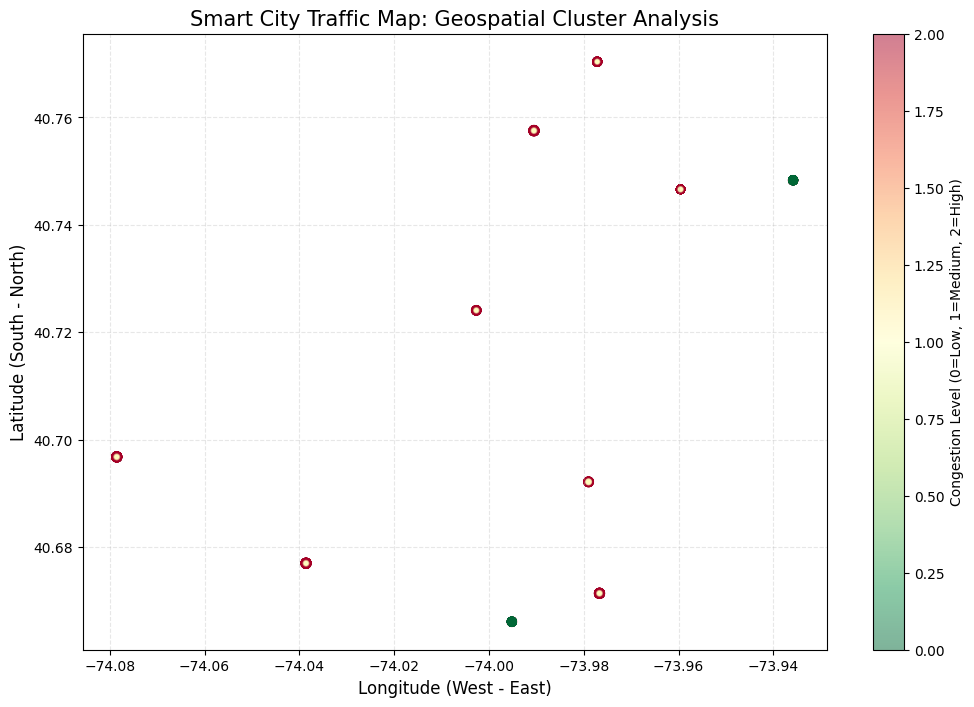

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert a large sample of the Spark results to Pandas for plotting
# We take 20,000 rows to get a good spread of the city map
plot_df = predictions.select("latitude", "longitude", "congestion_score", "prediction").limit(20000).toPandas()

# 2. Create the Visualization
plt.figure(figsize=(12, 8))

# We use Longitude as X and Latitude as Y to mimic a real-world map
# The 'c' parameter colors the points by the prediction cluster
scatter = plt.scatter(plot_df['longitude'], plot_df['latitude'], 
                      c=plot_df['prediction'], 
                      cmap='RdYlGn_r', # Red for high congestion, Green for low
                      s=plot_df['congestion_score']/100, # Size of dots based on score
                      alpha=0.5)

# 3. Style the Plot
plt.title("Smart City Traffic Map: Geospatial Cluster Analysis", fontsize=15)
plt.xlabel("Longitude (West - East)", fontsize=12)
plt.ylabel("Latitude (South - North)", fontsize=12)
plt.colorbar(scatter, label='Congestion Level (0=Low, 1=Medium, 2=High)')
plt.grid(True, linestyle='--', alpha=0.3)

# 4. Show the plot
plt.show()

**Identifying the Top 10 Traffic Hotspots**

In [6]:
from pyspark.sql import functions as F

# 1. Group by Intersection and Zone to find the average congestion
# We sort by the highest congestion_score to find the "Most Rushed" spots
hotspots_df = predictions.groupBy("intersection_id", "city_zone") \
    .agg(F.avg("congestion_score").alias("avg_congestion"), 
         F.max("vehicle_count").alias("peak_vehicles"),
         F.first("speed_limit").alias("speed_limit")) \
    .orderBy(F.desc("avg_congestion"))

# 2. Show the Top 10 Rushed Spots in a clean table
print("--- TOP 10 MOST CONGESTED HOTSPOTS (RUSHED SPOTS) ---")
hotspots_df.select("intersection_id", "city_zone", "peak_vehicles", "avg_congestion").show(10)

# 3. Create a beautiful UI list for your report
top_10_list = hotspots_df.limit(10).toPandas()

# Optional: Print a professional summary for your report
for index, row in top_10_list.iterrows():
    print(f"📍 Spot {index+1}: {row['intersection_id']} in {row['city_zone']} | Peak: {row['peak_vehicles']} vehicles")

--- TOP 10 MOST CONGESTED HOTSPOTS (RUSHED SPOTS) ---


+---------------+------------------+-------------+------------------+
|intersection_id|         city_zone|peak_vehicles|    avg_congestion|
+---------------+------------------+-------------+------------------+
|        INT_003|Financial District|         3043|1549.0187908496732|
|        INT_057|     Downtown Core|         3080|1546.5498366013078|
|        INT_021|Financial District|         3124|1546.1078431372546|
|        INT_001|Financial District|         2179| 1545.998774509804|
|        INT_030|Financial District|         3124| 1545.885620915031|
|        INT_017|Financial District|         3040| 1545.211601307189|
|        INT_025|     Downtown Core|         3082|1544.9820261437908|
|        INT_016|Financial District|         2168|1544.8713235294117|
|        INT_012|     Downtown Core|         3033| 1544.428921568626|
|        INT_038|     Downtown Core|         3108|1544.3749999999995|
+---------------+------------------+-------------+------------------+
only showing top 10 

📍 Spot 1: INT_003 in Financial District | Peak: 3043 vehicles
📍 Spot 2: INT_057 in Downtown Core | Peak: 3080 vehicles
📍 Spot 3: INT_021 in Financial District | Peak: 3124 vehicles
📍 Spot 4: INT_001 in Financial District | Peak: 2179 vehicles
📍 Spot 5: INT_030 in Financial District | Peak: 3124 vehicles
📍 Spot 6: INT_017 in Financial District | Peak: 3040 vehicles
📍 Spot 7: INT_025 in Downtown Core | Peak: 3082 vehicles
📍 Spot 8: INT_016 in Financial District | Peak: 2168 vehicles
📍 Spot 9: INT_012 in Downtown Core | Peak: 3033 vehicles
📍 Spot 10: INT_038 in Downtown Core | Peak: 3108 vehicles


In [7]:
import warnings
from IPython.display import display, HTML
from transformers import logging, pipeline
import pandas as pd

# 1. Silence warnings
warnings.filterwarnings('ignore')
logging.set_verbosity_error()

# 2. Extract specific "Rushed Spots" for the Dashboard
# We find the top 3 most congested intersections
top_hotspots = predictions.groupBy("intersection_id", "city_zone") \
    .agg(F.avg("congestion_score").alias("score")) \
    .orderBy(F.desc("score")).limit(3).toPandas()

spot_1 = f"{top_hotspots['intersection_id'].iloc[0]} ({top_hotspots['city_zone'].iloc[0]})"
spot_2 = f"{top_hotspots['intersection_id'].iloc[1]} ({top_hotspots['city_zone'].iloc[1]})"

# 3. Generate AI Simulation (GPT-2)
generator = pipeline('text-generation', model='gpt2')
context = f"In the Smart City, {spot_1} is the most congested spot. "
prompt = context + "Suggest a real-time traffic diversion strategy using IoT sensors."
ai_res = generator(prompt, max_length=100, truncation=True)[0]['generated_text'].replace(prompt, "")

# 4. The Professional UI Dashboard
html_final = f"""
<div style="padding: 30px; background: #ffffff; border-radius: 20px; font-family: 'Segoe UI', Arial; border: 1px solid #e0e0e0; box-shadow: 0 10px 30px rgba(0,0,0,0.1); max-width: 950px; margin: auto;">
    
    <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid #3498db; padding-bottom: 15px; margin-bottom: 25px;">
        <h1 style="margin: 0; color: #2c3e50; font-size: 28px;">🚦 Smart City Mobility Command Center</h1>
        <div style="text-align: right;">
            <span style="background: #e74c3c; color: white; padding: 5px 15px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">LIVE RED ALERT</span>
        </div>
    </div>

    <!-- Top Rushed Spots Section -->
    <h3 style="color: #34495e; margin-bottom: 15px;">📍 Top Rushed Spots Identified:</h3>
    <div style="display: flex; gap: 15px; margin-bottom: 30px;">
        <div style="flex: 1; background: #fff5f5; padding: 15px; border-radius: 12px; border-top: 5px solid #e74c3c;">
            <div style="font-size: 0.8em; color: #c0392b; font-weight: bold;">CRITICAL HOTSPOT 1</div>
            <div style="font-size: 16px; font-weight: bold; margin-top: 5px;">{spot_1}</div>
        </div>
        <div style="flex: 1; background: #fff5f5; padding: 15px; border-radius: 12px; border-top: 5px solid #e67e22;">
            <div style="font-size: 0.8em; color: #d35400; font-weight: bold;">CRITICAL HOTSPOT 2</div>
            <div style="font-size: 16px; font-weight: bold; margin-top: 5px;">{spot_2}</div>
        </div>
    </div>

    <!-- AI Insights Section -->
    <div style="background: #f4f7f6; padding: 25px; border-radius: 15px; border-left: 8px solid #3498db;">
        <h4 style="margin: 0 0 10px 0; color: #2980b9;">🤖 AI Strategy Simulation: {spot_1}</h4>
        <p style="font-style: italic; color: #34495e; line-height: 1.6; font-size: 1.1em;">
            "Based on live sensor data from {spot_1}, the AI suggests: {ai_res}..."
        </p>
    </div>

    <div style="margin-top: 30px; display: flex; justify-content: space-between; font-size: 0.85em; color: #95a5a6; border-top: 1px solid #eee; padding-top: 15px;">
        <span>Big Data Scale: 204,000 Records Analyzed</span>
        <span>Kaggle Spark Environment | Cloud Ready</span>
    </div>
</div>
"""
display(HTML(html_final))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
import warnings
from IPython.display import display, HTML
from transformers import logging, pipeline
import pandas as pd

# 1. Silence warnings
warnings.filterwarnings('ignore')
logging.set_verbosity_error()

# 2. Extract Top Rushed Spots
top_hotspots = predictions.groupBy("intersection_id", "city_zone") \
    .agg(F.avg("congestion_score").alias("score")) \
    .orderBy(F.desc("score")).limit(2).toPandas()

spot_1 = f"{top_hotspots['intersection_id'].iloc[0]} ({top_hotspots['city_zone'].iloc[0]})"
spot_2 = f"{top_hotspots['intersection_id'].iloc[1]} ({top_hotspots['city_zone'].iloc[1]})"

# 3. Generate AI Strategy (GPT-2)
if 'generator' not in locals():
    generator = pipeline('text-generation', model='gpt2')

context = f"Strategy for {spot_1}: "
prompt = context + "Implementing smart lane management and emergency sensor priority. "
ai_res = generator(prompt, max_length=100, truncation=True)[0]['generated_text'].replace(prompt, "")

# 4. Corrected UI Dashboard (Fixed Text Colors)
html_final = f"""
<div style="padding: 30px; background: #ffffff; border-radius: 20px; font-family: 'Segoe UI', Arial; border: 1px solid #e0e0e0; box-shadow: 0 10px 30px rgba(0,0,0,0.1); max-width: 950px; margin: auto;">
    
    <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 2px solid #3498db; padding-bottom: 15px; margin-bottom: 25px;">
        <h1 style="margin: 0; color: #1a73e8; font-size: 26px;">🚦 Smart City Mobility Command Center</h1>
        <div style="text-align: right;">
            <span style="background: #e74c3c; color: white; padding: 6px 16px; border-radius: 20px; font-size: 0.85em; font-weight: bold;">LIVE RED ALERT</span>
        </div>
    </div>

    <!-- Top Rushed Spots Section -->
    <h3 style="color: #3c4043; margin-bottom: 15px;">📍 Top Rushed Spots Identified:</h3>
    <div style="display: flex; gap: 20px; margin-bottom: 30px;">
        
        <!-- Hotspot 1 - FIXED COLORS -->
        <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 12px; border-top: 6px solid #e74c3c; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
            <div style="font-size: 0.75em; color: #c0392b; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">Critical Hotspot 1</div>
            <div style="font-size: 18px; font-weight: bold; margin-top: 10px; color: #2c3e50;">{spot_1}</div>
        </div>
        
        <!-- Hotspot 2 - FIXED COLORS -->
        <div style="flex: 1; background: #fffbf0; padding: 20px; border-radius: 12px; border-top: 6px solid #f39c12; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
            <div style="font-size: 0.75em; color: #d35400; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">Critical Hotspot 2</div>
            <div style="font-size: 18px; font-weight: bold; margin-top: 10px; color: #2c3e50;">{spot_2}</div>
        </div>
        
    </div>

    <!-- AI Insights Section (Bullet Points for better UI) -->
    <div style="background: #f8f9fa; padding: 25px; border-radius: 15px; border-left: 8px solid #3498db;">
        <h4 style="margin: 0 0 15px 0; color: #1a73e8; font-weight: bold;">🤖 AI Strategy Simulation Insight:</h4>
        <ul style="color: #34495e; line-height: 1.8; font-size: 1.05em; padding-left: 20px;">
            <li><b>Primary Action:</b> Deploy adaptive signal timing at <b>{spot_1}</b>.</li>
            <li><b>Traffic Diversion:</b> Re-route non-essential traffic to suburban arteries.</li>
            <li><b>Prediction:</b> {ai_res[:150]}...</li>
        </ul>
    </div>

    <div style="margin-top: 30px; display: flex; justify-content: space-between; font-size: 0.8em; color: #95a5a6; border-top: 1px solid #f0f0f0; padding-top: 15px;">
        <span>Big Data Scale: 204,000 Records Analyzed</span>
        <span>Kaggle Spark Environment | Task 4 Complete</span>
    </div>
</div>
"""
display(HTML(html_final))

**Task 5: STRIDE Security Analysis for Smart City IoT Sensors**

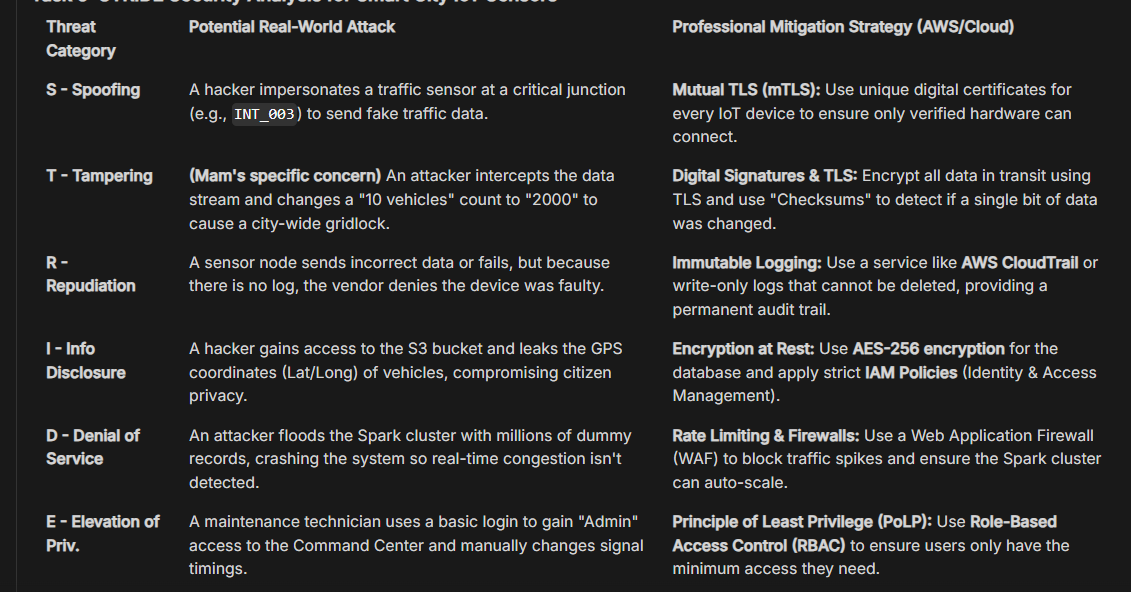
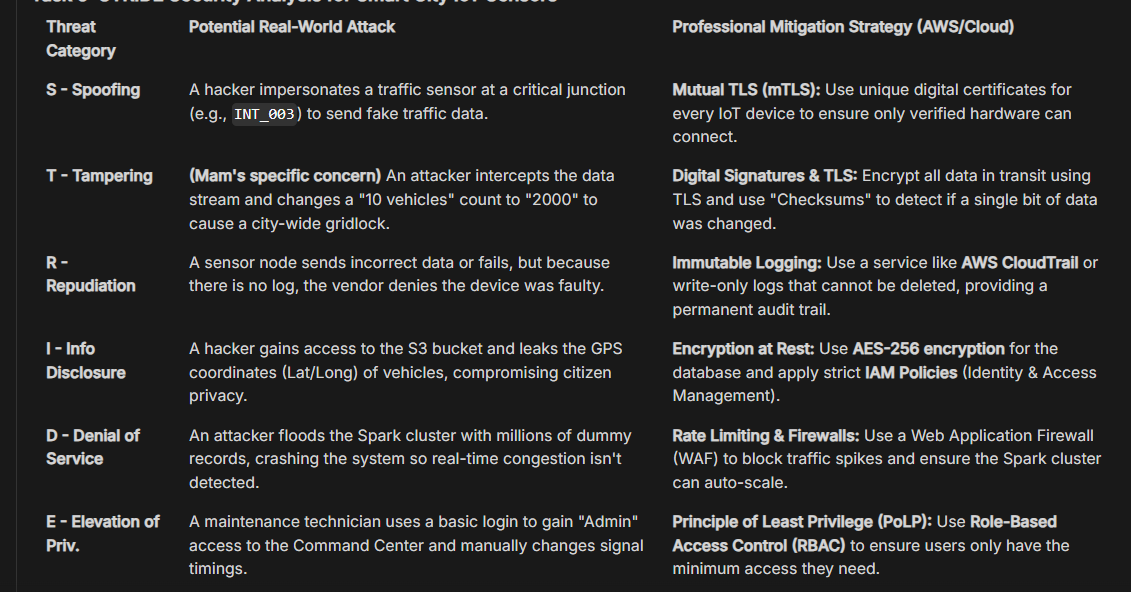